# Inverse Modeling example

We'll show a simple example for inverse modeling using automatic differentiation on a vertex model with bounded boundaries.

First, let's check that VertAX is correctly installed by importing all we'll need for the next parts

In [1]:
from vertax import BoundedBilevelOptimizer, BoundedMesh
# We'll see how to those important classes.

Now, let's create our initial mesh. It will have 20 cells, in a square domain.

In [2]:
import math

# Settings
n_cells = 20
# Square domain that will contain the seeds for the mesh creation
width = math.sqrt(n_cells)
height = width

# Create a new mesh with bounded boundaries, from an initial Voronoi graph with random seeds positions.
mesh = BoundedMesh.from_random_seeds(nb_seeds=n_cells, width=width, height=height, random_key=2)



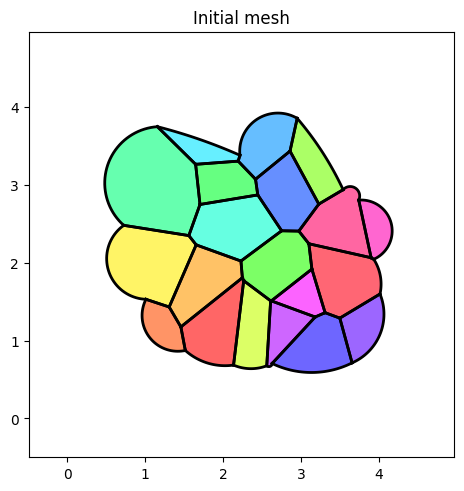

Created mesh has 20 cells, 57 edges and 38 vertices.


In [3]:
from vertax import plot_mesh

plot_mesh(mesh, title="Initial mesh")

print(f"Created mesh has {mesh.nb_faces} cells, {mesh.nb_edges} edges and {mesh.nb_vertices} vertices.")

The mesh is associated to parameters on vertices, (half-)edges and faces (cells). The meaning of these parameters is "given" by the loss functions.

In our example, we'll only focus on the parameters of the edges, which will be the tensions at given edge ; and the parameters for faces will be their area, fixed to 0.6.

In [4]:
import jax  # VertAX uses jax and manipulates jax arrays.
import jax.numpy as jnp  # Use it like numpy

# Set mesh parameters
# 1) We don't use vertices, basic initialization.
mesh.vertices_params = jnp.asarray([0.0 for _ in range(mesh.nb_vertices)])

# 2) We give a random tension to each edge.
key = jax.random.PRNGKey(3)  # change the seed for different results
mesh.edges_params = 1 + jax.nn.sigmoid(jax.random.uniform(key, (mesh.nb_edges,))* 20 - 10)
# As we have half-edges, this part is necessary so that corresponding half-edges have the same tension.
# mesh.edges_params = jnp.repeat(he_params, 2)

# 3) We set the faces areas to 0.6.
mesh.faces_params = jnp.asarray([0.6 for _ in range(mesh.nb_faces)])

It is time to define our custom inner loss function. This energy function will penalize cell areas different than 0.6 and the length of edges depending on the tension on them.

In [5]:
from jax import Array, vmap

from vertax.geo import (  # geometry functions to compute area of faces and length of edges
    get_area_bounded,
    get_edge_length,
    get_surface_length,
)
from vertax.opt_bounded import InnerLossFunctionBounded  # Only here for the type hint, not important


def get_energy_function() -> InnerLossFunctionBounded:
    """Helper function to get a customized energy function."""

    # Energy functions : Note that they use the width and height parameters defined earlier
    def area_part(
            face: Array, face_param: Array, vertTable: Array, angTable:Array, heTable: Array, faceTable: Array
            ) -> Array:
        """Area part of the energy function, per given faces."""
        a = get_area_bounded(face, vertTable, angTable, heTable, faceTable)
        return (a - face_param) ** 2

    def surface_edge_energy(edge: Array, tension: Array, vertTable: Array, angTable: Array, heTable: Array) -> Array:
        """Edge part of the energy function, for given edge. 0 for inner edges."""
        length = get_surface_length(edge, vertTable, angTable, heTable)
        return length * tension

    def inner_edge_energy(edge: Array, tension: Array, vertTable: Array, heTable: Array) -> Array:
        """Edge part of the energy function, for given edge. 0 for surface edges."""
        length = get_edge_length(edge, vertTable, heTable)
        return length * tension

    # It is important to define the energy function with this exact signature,
    # even though the "_vert_params" is unused, we still keep it.
    def energy_fct(
        vertTable: Array,
        angTable: Array,
        heTable: Array,
        faceTable: Array,
        _selected_verts: Array | None,
        _selected_hes: Array | None,
        _selected_faces: Array | None,
        _vert_params: Array,
        he_params: Array,
        face_params: Array,
    ) -> Array:
        """Custom energy function for the inner optimization. All parameters are required in the signature."""
        # Prepare data first
        # for bounded meshes the two first vertices are reserved values
        vertTable = jnp.vstack([jnp.array([[0.0, 0.0], [1.0, 1.0]]), vertTable])
        num_edges = angTable.size
        num_half_edges = num_edges * 2
        edges = jnp.arange(num_half_edges)
        unique_edges = jnp.arange(num_edges) * 2
        angTable = jnp.repeat(angTable, 2)  # repeat data for twin half-edges
        he_params = jax.nn.sigmoid(he_params) + 1

        K_areas = 20

        def mapped_areas_part(face: Array, face_param: Array) -> Array:
            return area_part(face, face_param, vertTable, angTable, heTable, faceTable)

        cell_area_energies = jnp.sum(vmap(mapped_areas_part)(jnp.arange(len(faceTable)), face_params))

        def mapped_surface_part(he: Array, tension: Array) -> Array:
            return surface_edge_energy(he, tension, vertTable, angTable, heTable)

        surface_edge_energies = jnp.sum(vmap(mapped_surface_part)(
                                                                                edges, jnp.repeat(he_params, 2)
                                                                              ))

        def mapped_inner_part(edge: Array, tension: Array) -> Array:
            return inner_edge_energy(edge, tension, vertTable, heTable)

        inner_edge_energies = jnp.sum(vmap(mapped_inner_part)(unique_edges, he_params))

        return K_areas * cell_area_energies + inner_edge_energies + surface_edge_energies

    return energy_fct

energy = get_energy_function()

Now we are ready to perform the inner optimization ! This part is done by a BoundedBilevelOptimizer, that stores the hyper-parameters for the optimizations.

Here are some parameters that are taken into account with the inner optimization :

In [6]:
import optax  # Defines solvers for the optimization problems

bilevel_optimizer = BoundedBilevelOptimizer()
bilevel_optimizer.loss_function_inner = energy  # Don't forget to set the loss function !
# Note: those are base values so the following can be ommited
bilevel_optimizer.inner_solver = optax.sgd(learning_rate=0.01)  # inner solver
bilevel_optimizer.update_T1 = True # Perform T1 transitions if necessary.
bilevel_optimizer.min_dist_T1 = 0.005  # Threshold to perform the T1 transitions.
bilevel_optimizer.max_nb_iterations = 1000  # Upper bound for the number of minimization operations
bilevel_optimizer.tolerance = 1e-4  # Below this level, we consider that the loss is stagnating
bilevel_optimizer.patience = 5  # Maximum number of consecutive stagnating loss before we stop.

Let's perform the inner optimization. It's as simple as that:

In [7]:
# Other paramerters are image_target (for cost_mesh2image), beta (for EP).
loss_history = bilevel_optimizer.inner_optimization(mesh)
# If you want to select only a subset of vertices, edges, and faces, it's possible:
# bilevel_optimizer.inner_optimization(mesh,
#     loss_function_inner=energy,
#     only_on_vertices=[list_vertex_ids],
#     only_on_edges=[list_edges_id],
#     only_on_faces=[list_faces_id],
# )

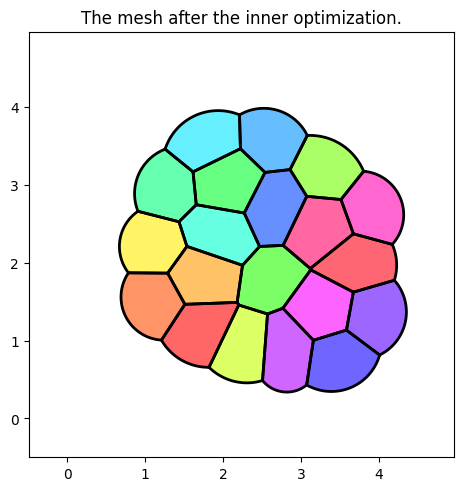

In [8]:
plot_mesh(mesh, title="The mesh after the inner optimization.")

The inner optimization nudged the mesh to minimize the length of edges with high tension while keeping the area of each face close to 0.6.

We'll use a bilevel optimization method now.

In addition to the previous parameters for the inner optimization, the following parameters are used during the bilevel optimization process:

In [9]:
from vertax.cost import cost_ratio  # We use a loss function defined by vertax, but you can use yours.

# This cost defines an approximate ratio between the long and short axes of our cellular cluster ;
# and compares the current ratio against a fixed target of 2.0,
# which corresponds to the goal to be achieved in this particular experiment.
bilevel_optimizer.loss_function_outer = cost_ratio

from vertax import BilevelOptimizationMethod  # An enumeration of the methods you can use

# Once again this part can be ommited because those are the base value for these parameters
bilevel_optimizer.outer_solver = optax.adam(learning_rate=0.0001, nesterov=True)  # outer solver
bilevel_optimizer.bilevel_optimization_method = BilevelOptimizationMethod.AUTOMATIC_DIFFERENTIATION

Let's run our bilevel optimization process. The first epoch is always a bit long but the next ones will be quick.

In a real simulation, a high number of epochs is necessary for a good result. Here, for this basic tutorial, we'll only use a few epochs.

(Also note that the performances are always worse in a notebook !)

In [10]:
from time import perf_counter

nb_epochs = 10

cost_history = []
for epoch in range(nb_epochs + 1):
    t_start = perf_counter()
    # This cost defines an approximate ratio between the long and short axes of our cellular cluster ;
    # and compares the current ratio against a fixed target of 2.0,
    # which corresponds to the goal to be achieved in this particular experiment.
    cost = cost_ratio(mesh.vertices)
    cost_history.append(cost)
    print(f"epoch: {epoch}/{nb_epochs}, actual cost is {cost}")

    loss_history = bilevel_optimizer.bilevel_optimization(mesh)
    print(f"epoch {epoch} took {perf_counter() - t_start} seconds.")

epoch: 0/10, actual cost is 0.7472109198570251
epoch 0 took 33.24964503599949 seconds.
epoch: 1/10, actual cost is 0.7465933561325073
epoch 1 took 4.4074065719996725 seconds.
epoch: 2/10, actual cost is 0.7459394335746765
epoch 2 took 4.526448525999513 seconds.
epoch: 3/10, actual cost is 0.7452759146690369
epoch 3 took 4.5276781789998495 seconds.
epoch: 4/10, actual cost is 0.7446077466011047
epoch 4 took 4.455566127999191 seconds.
epoch: 5/10, actual cost is 0.7439382672309875
epoch 5 took 4.6568274940000265 seconds.
epoch: 6/10, actual cost is 0.7432674169540405
epoch 6 took 4.655851982999593 seconds.
epoch: 7/10, actual cost is 0.7425972819328308
epoch 7 took 4.465580265999961 seconds.
epoch: 8/10, actual cost is 0.7419276237487793
epoch 8 took 4.639130183000816 seconds.
epoch: 9/10, actual cost is 0.7412607669830322
epoch 9 took 4.609698378999383 seconds.
epoch: 10/10, actual cost is 0.7405954003334045
epoch 10 took 4.627429799000311 seconds.


Just to check that the process is working, let's do a basic plot of the cost in function of the epoch.

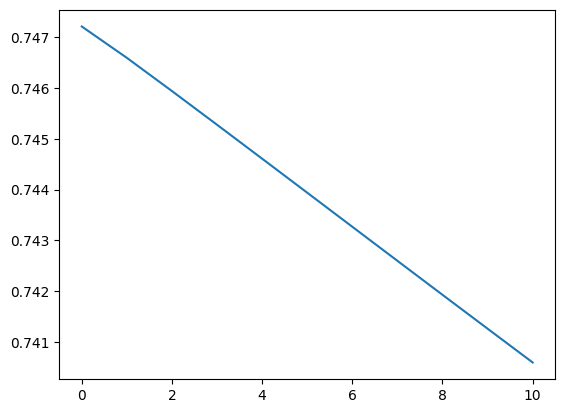

In [11]:
import matplotlib.pyplot as plt

plt.plot(range(nb_epochs+1), cost_history)

Of course, a higher number of epochs is necessary for the cost function to stabilize. If we plot the mesh after a sufficient number of epochs, we'll see that the vertices moved to match the tensions and area constraints.

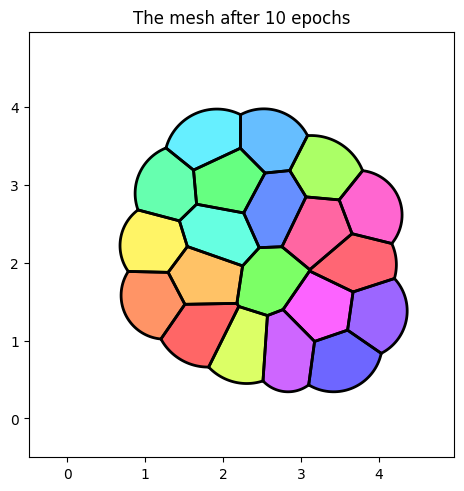

In [12]:
plot_mesh(mesh, title=f"The mesh after {nb_epochs} epochs")

We can also plot the tensions and areas:

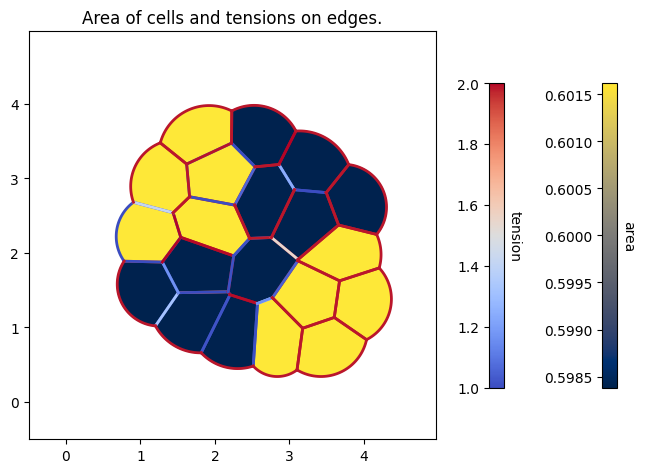

In [13]:
from vertax import EdgePlot, FacePlot, VertexPlot  # Enumerations to decide what to show on the plot.

plot_mesh(mesh, edge_plot=EdgePlot.EDGE_PARAMETER, edge_parameters_name="tension",
          face_plot=FacePlot.FACE_PARAMETER, face_parameters_name="area",
          vertex_plot=VertexPlot.INVISIBLE,
          title="Area of cells and tensions on edges.")